# DDPG Test

In [33]:
import sys
import gymnasium as gym
import torch
from gymnasium.wrappers import TimeLimit
from torch import Tensor, nn, optim
from torch.nn.functional import mse_loss
from tqdm import trange
sys.path.append("..")
from fnn import FNN
from utils import device, polyak_update


def add_transition(
  replay_state: Tensor,
  replay_action: Tensor,
  replay_reward: Tensor,
  replay_done: Tensor,
  replay_next_state: Tensor,
  replay_idx: int,
  replay_size: int,
  replay_capacity: int,
  state: Tensor,
  action: Tensor,
  reward: float,
  done: bool,
  next_state: Tensor,
) -> tuple[int, int]:
  replay_state[replay_idx].copy_(state)
  replay_action[replay_idx].copy_(action)
  replay_reward[replay_idx, 0] = float(reward)
  replay_done[replay_idx, 0] = 1.0 if done else 0.0
  replay_next_state[replay_idx].copy_(next_state)
  replay_idx = (replay_idx + 1) % replay_capacity
  replay_size = min(replay_size + 1, replay_capacity)
  return replay_idx, replay_size


def sample_batch(
  replay_state: Tensor,
  replay_action: Tensor,
  replay_reward: Tensor,
  replay_done: Tensor,
  replay_next_state: Tensor,
  replay_size: int,
  batch_size: int,
) -> tuple[Tensor, Tensor, Tensor, Tensor, Tensor]:
  idx = torch.randint(0, replay_size, (batch_size,), device = device)
  return replay_state[idx], replay_action[idx], replay_reward[idx], replay_done[idx], replay_next_state[idx]


env = gym.make("HalfCheetah-v5")
env = TimeLimit(env, max_episode_steps = 500)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_low = torch.tensor(env.action_space.low, dtype = torch.float32, device = device)
action_high = torch.tensor(env.action_space.high, dtype = torch.float32, device = device)

num_episodes = 5000
batch_size = 256
replay_capacity = 100000
gamma = 0.99
actor_lr = 3e-4
critic_lr = 3e-4
actor_polyak = 0.005
critic_polyak = 0.005
actor_update_interval = 1
update_every_steps = 20
noise_std = 0.2
noise_std_min = 0.0001
noise_std_decay = 0.9999
hidden_size = 256
num_hidden_layers = 3
print_interval = 200

actor = FNN(
  input_size = state_dim,
  hidden_size = hidden_size,
  num_hidden_layers = num_hidden_layers,
  output_size = action_dim,
  output_activation = nn.Tanh(),
).to(device)
critic = FNN(
  input_size = state_dim + action_dim,
  hidden_size = hidden_size,
  num_hidden_layers = num_hidden_layers,
  output_size = 1,
).to(device)
actor_target = FNN(
  input_size = state_dim,
  hidden_size = hidden_size,
  num_hidden_layers = num_hidden_layers,
  output_size = action_dim,
  output_activation = nn.Tanh(),
).to(device)
critic_target = FNN(
  input_size = state_dim + action_dim,
  hidden_size = hidden_size,
  num_hidden_layers = num_hidden_layers,
  output_size = 1,
).to(device)

for target_param, param in zip(actor_target.parameters(), actor.parameters()):
  target_param.data.copy_(param.data)
for target_param, param in zip(critic_target.parameters(), critic.parameters()):
  target_param.data.copy_(param.data)
for param in actor_target.parameters():
  param.requires_grad_(False)
for param in critic_target.parameters():
  param.requires_grad_(False)

actor_optimizer = optim.Adam(actor.parameters(), lr = actor_lr)
critic_optimizer = optim.Adam(critic.parameters(), lr = critic_lr)

replay_state = torch.empty((replay_capacity, state_dim), dtype = torch.float32, device = device)
replay_action = torch.empty((replay_capacity, action_dim), dtype = torch.float32, device = device)
replay_reward = torch.empty((replay_capacity, 1), dtype = torch.float32, device = device)
replay_done = torch.empty((replay_capacity, 1), dtype = torch.float32, device = device)
replay_next_state = torch.empty((replay_capacity, state_dim), dtype = torch.float32, device = device)
replay_idx = 0
replay_size = 0

episode_rewards = []
train_updates = 0
env_steps = 0

for episode in trange(num_episodes):
  state_np, _ = env.reset(seed = episode)
  state = torch.tensor(state_np, dtype = torch.float32, device = device)
  episode_reward = 0.0
  terminated = False
  truncated = False

  while not terminated and not truncated:
    with torch.no_grad():
      action = actor(state.unsqueeze(0))[0]
    action = action + torch.randn_like(action) * noise_std
    action = action.clamp(min = action_low, max = action_high)

    next_state_np, reward, terminated, truncated, _ = env.step(action.cpu().numpy())
    done = bool(terminated or truncated)
    next_state = torch.tensor(next_state_np, dtype = torch.float32, device = device)

    replay_idx, replay_size = add_transition(
      replay_state = replay_state,
      replay_action = replay_action,
      replay_reward = replay_reward,
      replay_done = replay_done,
      replay_next_state = replay_next_state,
      replay_idx = replay_idx,
      replay_size = replay_size,
      replay_capacity = replay_capacity,
      state = state,
      action = action,
      reward = float(reward),
      done = done,
      next_state = next_state,
    )

    state = next_state
    episode_reward += float(reward)
    env_steps += 1

    if replay_size >= batch_size and env_steps % update_every_steps == 0:
      batch_state, batch_action, batch_reward, batch_done, batch_next_state = sample_batch(
        replay_state = replay_state,
        replay_action = replay_action,
        replay_reward = replay_reward,
        replay_done = replay_done,
        replay_next_state = replay_next_state,
        replay_size = replay_size,
        batch_size = batch_size,
      )

      with torch.no_grad():
        next_action = actor_target(batch_next_state)
        next_state_action = torch.cat([batch_next_state, next_action], dim = 1)
        next_q = critic_target(next_state_action)
        target_q = batch_reward + (1.0 - batch_done) * gamma * next_q

      state_action = torch.cat([batch_state, batch_action], dim = 1)
      q = critic(state_action)
      critic_loss = mse_loss(q, target_q)
      critic_optimizer.zero_grad(set_to_none = True)
      critic_loss.backward()
      critic_optimizer.step()
      critic_optimizer.zero_grad(set_to_none = True)
      polyak_update(critic_target, critic, critic_polyak)

      actor_loss = torch.tensor(float("nan"), device = device)
      if train_updates % actor_update_interval == 0:
        actor_action = actor(batch_state)
        actor_state_action = torch.cat([batch_state, actor_action], dim = 1)
        actor_q = critic(actor_state_action)
        actor_loss = -actor_q.mean()
        actor_optimizer.zero_grad(set_to_none = True)
        actor_loss.backward()
        actor_optimizer.step()
        actor_optimizer.zero_grad(set_to_none = True)
        polyak_update(actor_target, actor, actor_polyak)

      train_updates += 1
      if train_updates % print_interval == 0:
        print(f"{train_updates}, cl: {critic_loss.item():.6f}, al: {actor_loss.item():.6f}, tq: {target_q.mean().item():.6f}, ns: {noise_std:.6f}, re: {episode_rewards[-1]:.6f}")

      noise_std = max(noise_std_min, noise_std * noise_std_decay)

  episode_rewards.append(episode_reward)

print("training_done", len(episode_rewards), episode_rewards[-1])
env.close()

  0%|          | 8/5000 [00:08<2:02:31,  1.47s/it]

200, cl: 0.015249, al: 0.593266, tq: -0.746686, ns: 0.196059, re: -250.520654


  0%|          | 16/5000 [00:25<2:48:51,  2.03s/it]

400, cl: 0.019149, al: 0.786284, tq: -1.121624, ns: 0.192177, re: -248.538433


  0%|          | 24/5000 [00:41<2:39:41,  1.93s/it]

...

1200, cl: 0.062815, al: 2.052736, tq: -2.294444, ns: 0.177401, re: -175.081760


  1%|          | 56/5000 [01:34<1:09:31,  1.19it/s]

1400, cl: 0.105316, al: 1.901579, tq: -2.389474, ns: 0.173888, re: -204.091661


  1%|          | 57/5000 [01:35<2:17:53,  1.67s/it]


KeyboardInterrupt: 

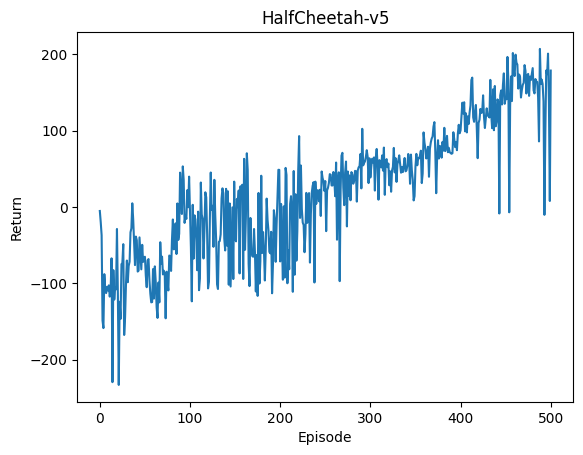

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("HalfCheetah-v5")
plt.show()

# Modular Test (non-RL)

In [1]:
import sys
import numpy as np
import torch
from torch.nn.functional import mse_loss
from torch.nn.utils import clip_grad_norm_
from tqdm import trange
sys.path.append("..")
from actor import Actor
from config import Config
from utils import device, polyak_update

input_dim = 16
batch_size = 512
steps = 20000
p = 2.5
print_interval = 200

rng = np.random.default_rng(0)

config = Config(
  state_dim = input_dim,
  action_dim = 1,
  action_tanh = False,
  num_encoders = 4,
  tree_depth = 3,
  critic_num_hidden_layers = 3,
  actor_num_hidden_layers = 5,
  embed_dim = 128,
  discount_rate = 0.99,
  learning_rate = 3e-4,
  critic_polyak_factor = 0.005,
  actor_polyak_factor = 0.005,
  batch_size = batch_size,
  num_episodes = 1,
  replay_buffer_size = 1,
  add_probability = 0.0,
  critic_update_interval = 5,
  actor_update_interval = 1,
  noise_std = 0.0,
  noise_std_min = 0.0,
  noise_std_decay = 1.0,
)

actor = Actor(config = config, rng = rng).to(device)

loss_history = []

for step in trange(steps):
  state = torch.rand((batch_size, input_dim), dtype = torch.float32, device = device)
  target = state.norm(p = p, dim = -1, keepdim = True)

  module_idx = int(rng.integers(0, len(actor._online_models)))
  _, action = actor(state, noise_std = 0.0, module_idx = module_idx)
  loss = mse_loss(action, target)

  actor._optimizers[module_idx].zero_grad(set_to_none = True)
  loss.backward()
  clip_grad_norm_(actor._online_models[module_idx].parameters(), max_norm = 1.0)
  actor._optimizers[module_idx].step()
  actor._optimizers[module_idx].zero_grad(set_to_none = True)

  polyak_update(
    actor._target_models[module_idx],
    actor._online_models[module_idx],
    config.actor_polyak_factor,
  )

  if step % print_interval == 0:
    loss_history.append(loss.item())
    print(f"{step}, loss: {loss.item():.6f}")

  0%|          | 7/20000 [00:01<39:30,  8.43it/s]  

0, loss: 2.298390


  1%|          | 214/20000 [00:04<04:34, 72.04it/s]

200, loss: 0.097907


  2%|▏         | 413/20000 [00:07<04:31, 72.07it/s]

...

 98%|█████████▊| 19612/20000 [03:20<00:03, 99.07it/s] 

19600, loss: 0.000100


 99%|█████████▉| 19820/20000 [03:22<00:01, 101.66it/s]

19800, loss: 0.000125


100%|██████████| 20000/20000 [03:24<00:00, 97.72it/s] 


# Modular Test (RL)

In [35]:
import sys
sys.path.append("..")
import numpy as np
import torch
import gymnasium as gym
from gymnasium.wrappers import TimeLimit
from config import Config
from collections import deque
from actor import Actor
from critic import Critic
from replay_buffer import ReplayBuffer
from tqdm import tqdm, trange
from utils import device

env = gym.make("HalfCheetah-v5")
env = TimeLimit(env, max_episode_steps = 200)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

from fnn import FNN
from torch import nn, optim
from torch.nn.functional import mse_loss
from torch.nn.utils import clip_grad_norm_
from utils import polyak_update

config = Config(
  state_dim = state_dim + action_dim,
  action_dim = 1,
  action_tanh = False,
  num_encoders = 2,
  tree_depth = 2,
  critic_num_hidden_layers = 4,
  actor_num_hidden_layers = 4,
  embed_dim = 32,
  discount_rate = 0.97,
  learning_rate = 1e-3,
  critic_polyak_factor = 0.05,
  actor_polyak_factor = 0.05,
  batch_size = 256,
  num_episodes = 5000,
  replay_buffer_size = 100000,
  add_probability = 1.0,
  critic_update_interval = None,
  actor_update_interval = None,
  noise_std = 0.05,
  noise_std_min = 0.0001,
  noise_std_decay = 0.9999,
)

rng = np.random.default_rng(0)
actor = FNN(
  input_size = state_dim,
  hidden_size = 128,
  num_hidden_layers = 4,
  output_size = action_dim,
  output_activation = nn.Tanh(),
).to(device)
critic = Actor(config, rng).to(device)
actor_target = FNN(
  input_size = state_dim,
  hidden_size = 128,
  num_hidden_layers = 4,
  output_size = action_dim,
  output_activation = nn.Tanh(),
).to(device)
actor_target.load_state_dict(actor.state_dict())
for param in actor_target.parameters():
  param.requires_grad_(False)

actor_optimizer = optim.Adam(actor.parameters(), lr = config.learning_rate)
replay = deque(maxlen = config.replay_buffer_size)
episode_rewards = []
noise_std = config.noise_std
train_updates = 0
update_interval = 7
env_steps = 0

for episode in trange(config.num_episodes):
  state_np, _ = env.reset(seed = episode)
  state = torch.tensor(state_np, dtype = torch.float32, device = device).unsqueeze(0)
  episode_reward = 0.0
  terminated = False
  truncated = False

  while not terminated and not truncated:
    with torch.no_grad():
      action = actor(state)
    action = action + torch.randn_like(action) * noise_std
    action = action.clamp(min = -2.0, max = 2.0)

    next_state_np, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
    next_state = torch.tensor(next_state_np, dtype = torch.float32, device = device).unsqueeze(0)
    reward_t = torch.tensor([[reward]], dtype = torch.float32, device = device)
    done_t = torch.tensor([[float(terminated or truncated)]], dtype = torch.float32, device = device)

    if rng.random() < config.add_probability:
      replay.append((state, action, reward_t, done_t, next_state))

    state = next_state
    episode_reward += float(reward)
    env_steps += 1

    if len(replay) >= config.batch_size and env_steps % update_interval == 0:
      indices = rng.integers(0, len(replay), size = config.batch_size)
      batch = [replay[i] for i in indices]
      batch_state = torch.cat([x[0] for x in batch], dim = 0)
      batch_action = torch.cat([x[1] for x in batch], dim = 0)
      batch_reward = torch.cat([x[2] for x in batch], dim = 0)
      batch_done = torch.cat([x[3] for x in batch], dim = 0)
      batch_next_state = torch.cat([x[4] for x in batch], dim = 0)

      module_idx = int(rng.integers(0, len(critic._online_models)))
      state_action = torch.cat([batch_state, batch_action], dim = 1)
      _, q = critic.forward(state_action, module_idx = module_idx)
      with torch.no_grad():
        next_action = actor_target(batch_next_state)
        next_state_action = torch.cat([batch_next_state, next_action], dim = 1)
        _, next_q = critic.forward(next_state_action, module_idx = -1)
        target_q = batch_reward + (1.0 - batch_done) * config.discount_rate * next_q

      critic_loss = mse_loss(q, target_q)
      critic._optimizers[module_idx].zero_grad(set_to_none = True)
      critic_loss.backward()
      clip_grad_norm_(critic._online_models[module_idx].parameters(), max_norm = 1.0)
      critic._optimizers[module_idx].step()
      critic._optimizers[module_idx].zero_grad(set_to_none = True)
      polyak_update(critic._target_models[module_idx], critic._online_models[module_idx], config.critic_polyak_factor)

      module_idx = np.random.randint(0, len(critic._online_models))
      actor_action = actor(batch_state)
      state_action = torch.cat([batch_state, actor_action], dim = 1)
      not_detach_idx = rng.integers(0, config.num_encoders)
      _, actor_q = critic.forward(state_action, module_idx = module_idx, not_detach_idx = not_detach_idx)
      actor_loss = -actor_q.mean()
      actor_optimizer.zero_grad(set_to_none = True)
      actor_loss.backward()
      clip_grad_norm_(actor.parameters(), max_norm = 1.0)
      actor_optimizer.step()
      actor_optimizer.zero_grad(set_to_none = True)
      polyak_update(actor_target, actor, config.actor_polyak_factor)

      train_updates += 1
      if train_updates % 200 == 0:
        print(f"{train_updates}, cl: {critic_loss.item():.6f}, al: {actor_loss.item():.6f}, tq: {target_q.mean().item():.6f}, ns: {noise_std:.6f}, re: {episode_rewards[-1] if episode_rewards else 0:.6f}")
      
      noise_std = max(config.noise_std_min, noise_std * config.noise_std_decay)

  episode_rewards.append(episode_reward)

episode_rewards

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 1/5000 [00:00<1:02:23,  1.34it/s]


TypeError: Actor.forward() got an unexpected keyword argument 'not_detach_idx'

### Modular Test (RL): sample video (`actor_target`)

In [31]:
import gymnasium as gym
import numpy as np
import os
import torch
from glob import glob
from gymnasium.wrappers import RecordVideo, TimeLimit
from IPython.display import Video

video_folder = "./videos/mod_rl_actor_target"
os.makedirs(video_folder, exist_ok = True)
video_env = gym.make("HalfCheetah-v5", render_mode = "rgb_array")
video_env = TimeLimit(video_env, max_episode_steps = 200)
video_env = RecordVideo(
  video_env,
  video_folder = video_folder,
  episode_trigger = lambda ep: ep == 0,
  name_prefix = "actor_target",
)
state_np, _ = video_env.reset(seed = 0)
terminated = False
truncated = False
while not terminated and not truncated:
  with torch.no_grad():
    state_t = torch.tensor(state_np, dtype = torch.float32, device = device).unsqueeze(0)
    action = actor_target(state_t)
  action_np = action.cpu().numpy().reshape(-1)
  action_np = np.clip(action_np, video_env.action_space.low, video_env.action_space.high)
  state_np, _, terminated, truncated, _ = video_env.step(action_np)
video_env.close()
paths = sorted(glob(os.path.join(video_folder, "*.mp4")))
Video(paths[-1], embed = True)

Exception ignored in: <function RecordVideo.__del__ at 0x000001CEB52EB100>
Traceback (most recent call last):
  File "c:\Users\abhay\anaconda3\envs\ursa25\Lib\site-packages\gymnasium\wrappers\rendering.py", line 433, in __del__
    if len(self.recorded_frames) > 0:
AttributeError: 'RecordVideo' object has no attribute 'recorded_frames'


# DDPG Test (Pendulum)

In [70]:
from collections import deque
from fnn import FNN
from torch import nn, optim
from torch.nn.functional import mse_loss
from torch.nn.utils import clip_grad_norm_
from utils import polyak_update

class TanhTimes2(nn.Module):
  def forward(self, x):
    return 2 * torch.tanh(x)

config = Config(
  state_dim = state_dim + action_dim,
  action_dim = 1,
  action_tanh = False,
  num_encoders = 2,
  tree_depth = 2,
  critic_num_hidden_layers = 4,
  actor_num_hidden_layers = 4,
  embed_dim = 32,
  discount_rate = 0.99,
  learning_rate = 1e-3,
  critic_polyak_factor = 0.01,
  actor_polyak_factor = 0.01,
  batch_size = 64,
  num_episodes = 5000,
  replay_buffer_size = 100000,
  add_probability = 1.0,
  critic_update_interval = None,
  actor_update_interval = None,
  noise_std = 0.1,
  noise_std_min = 0.0001,
  noise_std_decay = 0.9999,
)

rng = np.random.default_rng(0)
actor = FNN(
  input_size = state_dim,
  hidden_size = 128,
  num_hidden_layers = 4,
  output_size = action_dim,
  output_activation = TanhTimes2(),
).to(device)
critic = FNN(
  input_size = state_dim + action_dim,
  hidden_size = 128,
  num_hidden_layers = 4,
  output_size = 1,
).to(device)
actor_target = FNN(
  input_size = state_dim,
  hidden_size = 128,
  num_hidden_layers = 4,
  output_size = action_dim,
  output_activation = TanhTimes2(),
).to(device)
critic_target = FNN(
  input_size = state_dim + action_dim,
  hidden_size = 128,
  num_hidden_layers = 4,
  output_size = 1,
).to(device)
actor_target.load_state_dict(actor.state_dict())
critic_target.load_state_dict(critic.state_dict())
for param in actor_target.parameters():
  param.requires_grad_(False)
for param in critic_target.parameters():
  param.requires_grad_(False)

actor_optimizer = optim.Adam(actor.parameters(), lr = config.learning_rate)
critic_optimizer = optim.Adam(critic.parameters(), lr = config.learning_rate)
replay = deque(maxlen = config.replay_buffer_size)
episode_rewards = []
noise_std = config.noise_std
train_updates = 0
update_interval = 5
env_steps = 0

for episode in trange(config.num_episodes):
  state_np, _ = env.reset(seed = episode)
  state = torch.tensor(state_np, dtype = torch.float32, device = device).unsqueeze(0)
  episode_reward = 0.0
  terminated = False
  truncated = False

  while not terminated and not truncated:
    with torch.no_grad():
      action = actor(state)
    action = action + torch.randn_like(action) * noise_std
    action = action.clamp(min = -2.0, max = 2.0)

    next_state_np, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
    next_state = torch.tensor(next_state_np, dtype = torch.float32, device = device).unsqueeze(0)
    reward_t = torch.tensor([[reward]], dtype = torch.float32, device = device)
    done_t = torch.tensor([[float(terminated or truncated)]], dtype = torch.float32, device = device)

    if rng.random() < config.add_probability:
      replay.append((state, action, reward_t, done_t, next_state))

    state = next_state
    episode_reward += float(reward)
    env_steps += 1

    if len(replay) >= config.batch_size and env_steps % update_interval == 0:
      indices = rng.integers(0, len(replay), size = config.batch_size)
      batch = [replay[i] for i in indices]
      batch_state = torch.cat([x[0] for x in batch], dim = 0)
      batch_action = torch.cat([x[1] for x in batch], dim = 0)
      batch_reward = torch.cat([x[2] for x in batch], dim = 0)
      batch_done = torch.cat([x[3] for x in batch], dim = 0)
      batch_next_state = torch.cat([x[4] for x in batch], dim = 0)

      critic_state = torch.cat([batch_state, batch_action], dim = 1)
      q = critic(critic_state)
      with torch.no_grad():
        next_action = actor_target(batch_next_state)
        next_critic_state = torch.cat([batch_next_state, next_action], dim = 1)
        next_q = critic_target(next_critic_state)
        target_q = batch_reward + (1.0 - batch_done) * config.discount_rate * next_q

      critic_loss = mse_loss(q, target_q)
      critic_optimizer.zero_grad(set_to_none = True)
      critic_loss.backward()
      clip_grad_norm_(critic.parameters(), max_norm = 1.0)
      critic_optimizer.step()
      critic_optimizer.zero_grad(set_to_none = True)
      polyak_update(critic_target, critic, config.critic_polyak_factor)

      actor_action = actor(batch_state)
      actor_critic_state = torch.cat([batch_state, actor_action], dim = 1)
      q = critic(actor_critic_state)
      actor_loss = -q.mean()
      actor_optimizer.zero_grad(set_to_none = True)
      actor_loss.backward()
      clip_grad_norm_(actor.parameters(), max_norm = 1.0)
      actor_optimizer.step()
      actor_optimizer.zero_grad(set_to_none = True)
      polyak_update(actor_target, actor, config.actor_polyak_factor)

      train_updates += 1
      if train_updates % 100 == 0:
        print(f"{train_updates}, cl: {critic_loss.item():.6f}, al: {actor_loss.item():.6f}, tq: {target_q.mean().item():.6f}, ns: {noise_std:.6f}, re: {episode_reward:.6f}")
      noise_std = max(config.noise_std_min, noise_std * config.noise_std_decay)

  episode_rewards.append(episode_reward)

episode_rewards

  0%|          | 2/5000 [00:02<1:52:17,  1.35s/it]

100, cl: 6.840099, al: 10.208994, tq: -12.089617, ns: 0.099015, re: -1189.113775


  0%|          | 5/5000 [00:06<1:39:13,  1.19s/it]

200, cl: 1.629097, al: 19.327614, tq: -19.882580, ns: 0.098030, re: -465.807804


  0%|          | 7/5000 [00:08<1:36:04,  1.15s/it]

...

7100, cl: 2.633662, al: 31.167181, tq: -31.991507, ns: 0.049168, re: -9.618921


  4%|▎         | 180/5000 [03:35<1:42:09,  1.27s/it]

7200, cl: 1.993951, al: 59.825012, tq: -62.019173, ns: 0.048678, re: -131.747050


  4%|▎         | 181/5000 [03:37<1:36:36,  1.20s/it]


KeyboardInterrupt: 

In [ ]:
import gymnasium as gym
import numpy as np
import os
import torch
from glob import glob
from gymnasium.wrappers import RecordVideo
from IPython.display import Video

rollout_env_id = "HalfCheetah-v5"
video_folder = "./videos/ddpg_actor_target_sample"
os.makedirs(video_folder, exist_ok = True)
video_env = gym.make(rollout_env_id, render_mode = "rgb_array")
video_env = RecordVideo(
  video_env,
  video_folder = video_folder,
  episode_trigger = lambda ep: ep == 0,
  name_prefix = "actor_target",
)
state_np, _ = video_env.reset(seed = 0)
terminated = False
truncated = False
while not terminated and not truncated:
  with torch.no_grad():
    state_t = torch.tensor(state_np, dtype = torch.float32, device = device).unsqueeze(0)
    action = actor_target(state_t)
  action_np = action.cpu().numpy().reshape(-1)
  action_np = np.clip(action_np, video_env.action_space.low, video_env.action_space.high)
  state_np, _, terminated, truncated, _ = video_env.step(action_np)
video_env.close()
paths = sorted(glob(os.path.join(video_folder, "*.mp4")))
Video(paths[-1], embed = True)